In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataset import train_dataset, test_dataset
import matplotlib.pyplot as plt

# UNDERSTANDING THE DATASET

In [3]:
len(train_dataset)

60000

In [4]:
image, label = train_dataset[0]

print(image.shape)
print(image.dtype)
print(image.min())
print(image.max())
print(label)

torch.Size([1, 28, 28])
torch.float32
tensor(0.)
tensor(1.)
5


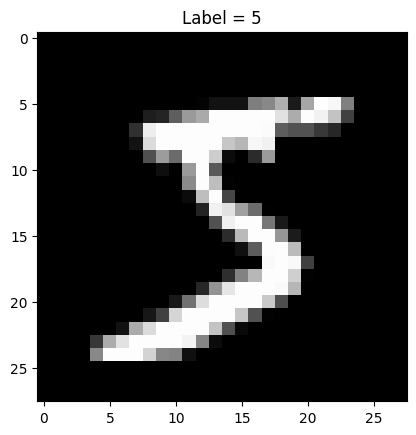

In [5]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label = {label}")
plt.show()

# FOR 1 TRAINING IMAGE


In [ ]:
image=image.unsqueeze(0) #since conv2d requires batch size too we unsqueeze it
image.shape

torch.Size([1, 1, 28, 28])

In [54]:
layer1=nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3,stride=1,padding=1)

In [55]:
out=layer1(image)
print(out.shape)

torch.Size([1, 16, 28, 28])


In [56]:
print(layer1.weight.shape)

torch.Size([16, 1, 3, 3])


In [10]:
relu=nn.ReLU()

In [11]:
out=relu(out)

In [12]:
pool=nn.MaxPool2d(kernel_size=2,stride=2)
out=pool(out)


In [14]:
print(out.shape)

torch.Size([1, 16, 14, 14])


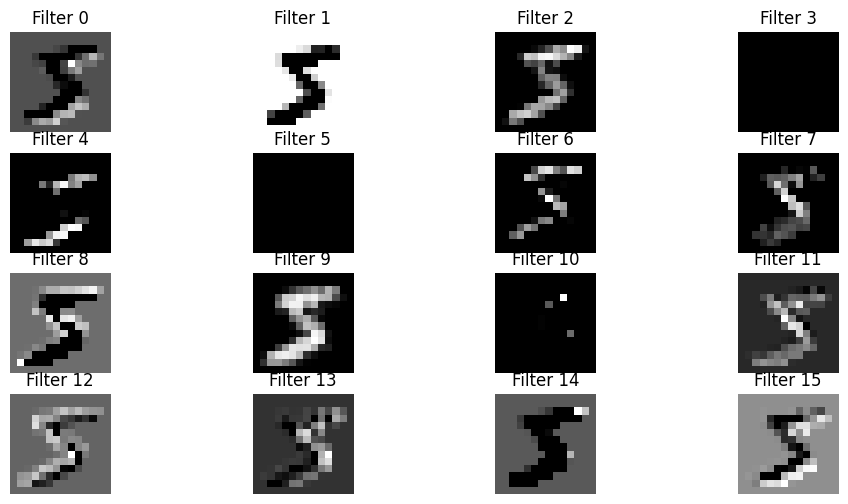

In [15]:
plt.figure(figsize=(12,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(out[0, i].detach().numpy(), cmap="gray")
    plt.title(f"Filter {i}")
    plt.axis("off")

plt.show()

In [42]:
flatten=nn.Flatten()

In [57]:
print(flatten)
type(flatten)

Flatten(start_dim=1, end_dim=-1)


torch.nn.modules.flatten.Flatten

In [36]:
fc = nn.Linear(3136, 10)


In [49]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    list(layer1.parameters()) +
    list(fc.parameters()),
    lr=0.01
)

In [50]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [43]:
print(type(layer1))
print(type(relu))
print(type(pool))
print(type(flatten))
print(type(fc))

<class 'torch.nn.modules.conv.Conv2d'>
<class 'torch.nn.modules.activation.ReLU'>
<class 'torch.nn.modules.pooling.MaxPool2d'>
<class 'torch.nn.modules.flatten.Flatten'>
<class 'torch.nn.modules.linear.Linear'>


In [51]:
epochs = 5

for epoch in range(epochs):

    running_loss = 0

    for images, labels in train_loader:

        # Forward
        out = layer1(images)
        out = relu(out)
        out = pool(out)
        out = flatten(out)
        out = fc(out)

        # Loss
        loss = criterion(out, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}: {running_loss/len(train_loader):.4f}")

Epoch 1: 0.5283
Epoch 2: 0.0902
Epoch 3: 0.0602
Epoch 4: 0.0508
Epoch 5: 0.0432


In [53]:
image, label = test_dataset[0]

image = image.unsqueeze(0)

out = layer1(image)
out = relu(out)
out = pool(out)
out = flatten(out)
out = fc(out)

pred = torch.argmax(out)

print("Prediction:", pred.item())
print("Actual:", label)

Prediction: 7
Actual: 7


# FULL PIPELINE

In [59]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Linear(16 * 14 * 14, 10)

    def forward(self, x):

        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc(x)

        return x

In [60]:
model = SimpleCNN()

print(model)

SimpleCNN(
  (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=3136, out_features=10, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/5 | Loss: 0.3254
Epoch 2/5 | Loss: 0.1302
Epoch 3/5 | Loss: 0.0864
Epoch 4/5 | Loss: 0.0690
Epoch 5/5 | Loss: 0.0593


In [63]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        predicted = torch.argmax(outputs, dim=1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 97.80%
